# Biomedical Image Analysis in Python
# CHAPTER 5: BODY COMPOSITION ANALYSIS FROM CT
### *An applied chapter — `qradiomics` + `TotalSegmentator` on a real chest CT*

Chapters 1–4 taught the primitives: load an N-dimensional image, build a mask, filter it, measure it,
and compare two images. This chapter puts all four to work on a task that is used every day in clinical
research: **body composition analysis (BCA)**.

Body composition analysis answers a question a BMI number cannot: *what is the patient actually made of?*
Two patients with identical height, weight and BMI can have completely different amounts of muscle and
fat, and it is the **tissue distribution**, not the total mass, that predicts outcome.

| Compartment | Abbrev. | What it is | Why it matters |
|---|---|---|---|
| Skeletal muscle | **SM / SMA** | Abdominal wall + paraspinal (and psoas) muscle | Low muscle area = **sarcopenia** → post-operative complications, chemotherapy toxicity, shorter survival |
| Muscle radiodensity | **SMD** | Mean HU inside the muscle mask | Low HU = fat-infiltrated muscle (**myosteatosis**) → poor muscle quality, an independent prognostic marker |
| Visceral adipose tissue | **VAT** | Fat *inside* the abdominal cavity | Metabolically active; linked to insulin resistance, inflammation, cardiovascular risk |
| Subcutaneous adipose tissue | **SAT** | Fat *outside* the abdominal wall, under the skin | Metabolically more benign; the VAT/SAT ratio is itself a risk marker |

The attractive thing about BCA is that **it is free**: every diagnostic CT that covers the abdomen
already contains the information. No extra scan, no extra dose. All that is needed is a reproducible way
to turn Hounsfield units into square centimetres — which is exactly what this notebook builds.

> ⚠️ **This notebook is educational.** The measurements produced here are *not* validated for clinical
> decision making. The limitations are listed explicitly in section 11 — please read them.

## 0. What we are going to build

We follow the canonical four-stage imaging-research flow used by the
[`qradiomics`](https://github.com/choilab-jefferson/qradiomics) toolkit:

```
   data              image                     features                 modeling
 ┌────────┐   ┌────────────────────┐   ┌────────────────────────┐   ┌──────────────┐
 │ DICOM  │ → │ NRRD volume +      │ → │ areas (cm²), density   │ → │ association  │
 │ series │   │ compartment masks  │   │ (HU), radiomic texture │   │ with outcome │
 └────────┘   └────────────────────┘   └────────────────────────┘   └──────────────┘
   qr convert     TotalSegmentator          qr extract                qr analyze
                  + HU thresholds        (PyRadiomics engine)          qr ml
```

Three tools, each doing what it is best at:

| Tool | Role in this notebook |
|---|---|
| **`qradiomics` (`qr`)** | DICOM → NRRD conversion, manifest handling, PyRadiomics feature extraction, and the cohort-scale workflow/statistics commands |
| **[TotalSegmentator](https://github.com/wasserth/TotalSegmentator)** | A pretrained nnU-Net that labels 117 anatomical structures in a CT. We use it for the two things a threshold can never do: **(a)** find the anatomical level (vertebra) and **(b)** tell the abdominal cavity from the abdominal wall |
| **`scipy.ndimage` / `scikit-image`** | The Chapter 2–3 primitives: filters, thresholds, morphology, connected components, measurement |

### Why not thresholds alone?

Fat and muscle *do* occupy distinct HU ranges, so a naive pipeline looks tempting:

```python
fat    = (-190 <= hu) & (hu <= -30)
muscle = ( -29 <= hu) & (hu <= 150)
```

But an HU value has no idea where it is. A threshold cannot tell:

* subcutaneous fat from visceral fat (**identical HU**, different compartment),
* abdominal wall muscle from the edge of the liver (**both ≈ 50 HU**),
* the patient from the scanner table and the patient's arms (all solid tissue-density objects).

That is *anatomical* knowledge, and it is precisely what a pretrained segmentation network supplies.
The recipe below is therefore **anatomy-guided thresholding**: TotalSegmentator defines *where*,
Hounsfield units define *what*.

## 1. Environment

```bash
# core toolkit (this notebook's kernel)
pip install qradiomics                # or: pip install -e . from a local clone
pip install SimpleITK scikit-image scipy pandas matplotlib

# TotalSegmentator — install into its own virtual environment so that its
# torch / nnU-Net pins cannot clash with the analysis kernel
python -m venv .venv-ts
.venv-ts/bin/pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
.venv-ts/bin/pip install TotalSegmentator
```

The notebook calls TotalSegmentator **as a command line tool** (`subprocess`), so the two environments
never have to agree on a torch version. On first run the model weights (~1.5 GB) are downloaded to
`~/.totalsegmentator/`. A GPU is *not* required: the 3 mm (`--fast`) model segments this 30-slice series
in about 25 s on CPU.

> **A note on licensing.** TotalSegmentator ships a dedicated `tissue_types` task
> (`subcutaneous_fat`, `torso_fat`, `skeletal_muscle`) that solves compartment segmentation in one call —
> but that task requires a license key (free for non-commercial use) and its weights are not part of the
> default download:
> ```bash
> totalseg_set_license -l aca_XXXXXXXXXXXX
> TotalSegmentator -i ct.nii.gz -o seg_tissue -ta tissue_types
> ```
> This notebook deliberately uses only the **freely available** `total` and `body` tasks and derives the
> compartments itself — so that everything below is reproducible without a key, and so that you see how
> the compartments are actually *defined* instead of receiving them from a black box.

In [1]:
import os, sys, json, glob, shutil, logging, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
import scipy.ndimage as ndi
import matplotlib.pyplot as plt

import radiomics
radiomics.setVerbosity(logging.CRITICAL)                 # PyRadiomics is chatty; keep the notebook readable
logging.getLogger("radiomics").setLevel(logging.CRITICAL)

# ----------------------------------------------------------------------------- paths
DICOM_DIR = Path("Data/ID00007637202177411956430")   # one CT series (30 slices)
WORK      = Path("work"); WORK.mkdir(exist_ok=True)
PATIENT   = DICOM_DIR.name

CT_NRRD   = WORK / f"{PATIENT}_CT.nrrd"      # qradiomics / PyRadiomics input
CT_NIFTI  = WORK / f"{PATIENT}_CT.nii.gz"    # TotalSegmentator input
SEG_DIR   = WORK / "seg"                     # TotalSegmentator 'total' output
BODY_DIR  = WORK / "seg_body"                # TotalSegmentator 'body'  output

# ------------------------------------------------------------------- TotalSegmentator
TS_BIN    = shutil.which("TotalSegmentator") or str(Path(".venv-ts/bin/TotalSegmentator").resolve())
TS_FAST   = True    # True -> 3 mm model (~25 s on CPU); False -> 1.5 mm model (sharper organ borders)
TS_DEVICE = "gpu" if shutil.which("nvidia-smi") else "cpu"

# --------------------------------------------------------------- analysis parameters
TARGET_VERTEBRA   = "vertebrae_L3"  # the clinical standard level; we fall back if it is not in the FOV
MIN_VERTEBRA_VOX  = 500             # ignore a vertebra that is only clipped by the edge of the FOV
SLAB_HALF_SLICES  = 1               # radiomics slab = target slice +/- 1 slice
PATIENT_HEIGHT_M  = 1.70            # NOT in the public DICOM header -> supply your own before quoting SMI

# Hounsfield unit windows (Mitsiopoulos 1998; Kvist 1988 — the de-facto BCA standard)
HU_FAT    = (-190, -30)
HU_MUSCLE = ( -29, 150)
HU_IMAT   = (-190, -30)   # same window as fat, but *inside* the muscle envelope
HU_AIR    = -500          # body / background separation

print("qradiomics :", subprocess.run(["qr", "--version"], capture_output=True, text=True).stdout.strip())
print("TS binary  :", TS_BIN, "| exists:", Path(TS_BIN).exists(), "| device:", TS_DEVICE)
print("patient    :", PATIENT, "|", len(list(DICOM_DIR.glob('*.dcm'))), "DICOM slices")

qradiomics : qradiomics, version 0.9.0
TS binary  : /home/wxc151/projects/Biomedical-Image-Analysis-in-Python/.venv-ts/bin/TotalSegmentator | exists: True | device: cpu
patient    : ID00007637202177411956430 | 30 DICOM slices


## 2. Stage `data` — DICOM → NRRD

`qr convert dicom-series` wraps SimpleITK's GDCM reader and does three things a plain
`imageio.volread()` does not:

1. **Sorts by series UID and image position**, not by file name (`10.dcm` sorts before `2.dcm`!),
2. **Applies the rescale slope/intercept**, so the output really is in Hounsfield units,
3. Routes PET series through an SUV conversion instead (`--modality PT`).

Point 2 is not cosmetic. Every threshold in this notebook is an HU value, so a volume still in raw
stored values is silently wrong by the rescale intercept (here: **−1024**).

In [2]:
if not CT_NRRD.exists():
    subprocess.run(["qr", "convert", "dicom-series",
                    "-i", str(DICOM_DIR), "-o", str(CT_NRRD)], check=True)

ct  = sitk.ReadImage(str(CT_NRRD))
vol = sitk.GetArrayFromImage(ct).astype(np.float32)          # (z, y, x), Hounsfield units
sx, sy, sz = ct.GetSpacing()                                 # mm

if not CT_NIFTI.exists():          # TotalSegmentator reads NIfTI — same grid, different container
    sitk.WriteImage(ct, str(CT_NIFTI))

PIXEL_AREA_CM2 = sx * sy / 100.0        # mm^2 -> cm^2
VOXEL_VOL_CM3  = sx * sy * sz / 1000.0  # mm^3 -> cm^3

print(f"shape (z,y,x)     : {vol.shape}")
print(f"spacing (x,y,z) mm: ({sx:.3f}, {sy:.3f}, {sz:.3f})")
print(f"HU range          : {vol.min():.0f} .. {vol.max():.0f}")
print(f"pixel area        : {PIXEL_AREA_CM2:.5f} cm^2   (this is the number that turns pixels into cm^2)")

shape (z,y,x)     : (30, 512, 512)
spacing (x,y,z) mm: (0.652, 0.652, 10.000)
HU range          : -3024 .. 2330
pixel area        : 0.00426 cm^2   (this is the number that turns pixels into cm^2)


### Know your data before you measure it

This series is a **chest** CT from the OSIC pulmonary fibrosis cohort, and it has two properties that
shape everything downstream. Never skip this step — an honest description of the input is part of the
measurement.

* **10 mm slice spacing.** A single axial slice is the standard unit of BCA anyway, so this is workable,
  but the "level" we choose is only accurate to ±5 mm and 3D shape features are unreliable.
* **A sharp (BONE) reconstruction kernel.** Sharp kernels amplify noise enormously. We quantify this
  below, because an HU threshold applied to a noisy image does not measure tissue — it measures noise.

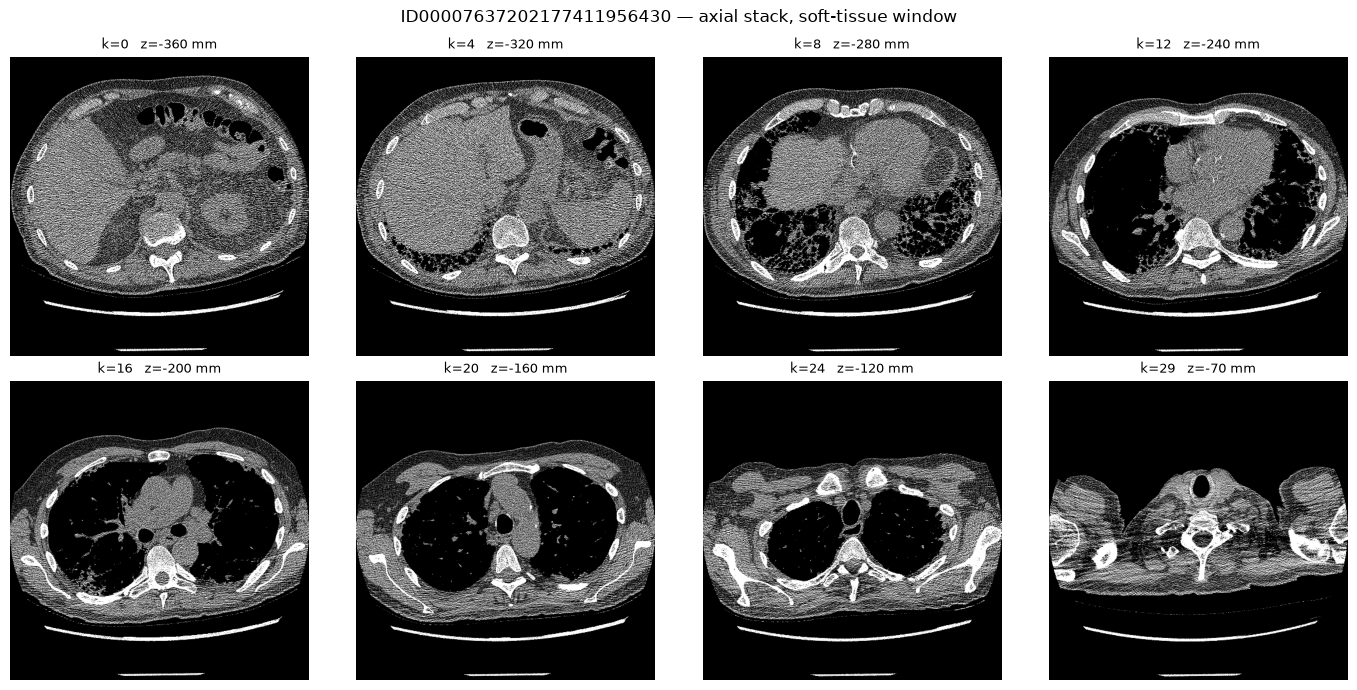

k=0  is the most inferior slice (upper abdomen: liver, stomach, spleen)
k=29 is the most superior slice (thoracic inlet)


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, k in zip(axes.ravel(), np.linspace(0, vol.shape[0] - 1, 8).astype(int)):
    z = ct.TransformIndexToPhysicalPoint((0, 0, int(k)))[2]
    ax.imshow(vol[k], cmap="gray", vmin=-160, vmax=240)   # soft-tissue window (W400/L40)
    ax.set_title(f"k={k}   z={z:.0f} mm", fontsize=9); ax.axis("off")
fig.suptitle(f"{PATIENT} — axial stack, soft-tissue window", y=0.98)
plt.tight_layout(); plt.show()

print("k=0  is the most inferior slice (upper abdomen: liver, stomach, spleen)")
print("k=29 is the most superior slice (thoracic inlet)")

## 3. Stage `image` (a) — TotalSegmentator supplies the anatomy

Two calls, both using freely available models:

| Call | Output | Used for |
|---|---|---|
| `-ta total` (default) | 117 structures: organs, vessels, **every vertebra**, ribs, paraspinal muscle | the analysis level, the visceral cavity, and the structures to exclude |
| `-ta body` | `body`, `body_trunc`, `body_extremities`, `skin` | a body mask that excludes the **scanner table and the arms** |

With `--fast` the 3 mm model runs in ~25 s on CPU for this 30-slice series. Drop `--fast` for the
1.5 mm model when organ boundaries need to be tight (about 4 min on CPU here).

In [4]:
def run_totalsegmentator(task=None, outdir=None, fast=TS_FAST):
    cmd = [TS_BIN, "-i", str(CT_NIFTI), "-o", str(outdir), "-d", TS_DEVICE]
    if fast: cmd.append("--fast")
    if task: cmd += ["-ta", task]
    print(">", " ".join(cmd))
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-2000:]); print(r.stderr[-2000:]); raise RuntimeError("TotalSegmentator failed")
    return outdir

if not SEG_DIR.exists():   run_totalsegmentator(task=None,   outdir=SEG_DIR)            # 'total'
if not BODY_DIR.exists():  run_totalsegmentator(task="body", outdir=BODY_DIR, fast=False)

masks_total = sorted(p.name[:-7] for p in SEG_DIR.glob("*.nii.gz"))
print(f"\n'total' produced {len(masks_total)} structure masks, e.g. {', '.join(masks_total[:6])} ...")
print("'body'  produced :", ", ".join(sorted(p.name[:-7] for p in BODY_DIR.glob('*.nii.gz'))))


'total' produced 117 structure masks, e.g. adrenal_gland_left, adrenal_gland_right, aorta, atrial_appendage_left, autochthon_left, autochthon_right ...
'body'  produced : body, body_extremities, body_trunc, skin


In [5]:
def load_mask(name, root=SEG_DIR):
    # Load one TotalSegmentator structure as a boolean array on the CT grid.
    p = Path(root) / f"{name}.nii.gz"
    return sitk.GetArrayFromImage(sitk.ReadImage(str(p))).astype(bool) if p.exists() else None

def union_masks(names, root=SEG_DIR):
    acc = np.zeros(vol.shape, bool)
    for n in names:
        m = load_mask(n, root)
        if m is not None:
            acc |= m
    return acc

# which structures did the network actually find in this (chest) field of view?
found = {n: int(load_mask(n).sum()) for n in masks_total}
found = {k: v for k, v in sorted(found.items(), key=lambda kv: -kv[1]) if v > 0}
print(f"{len(found)} of {len(masks_total)} structures are present in this FOV. Ten largest:")
for n, v in list(found.items())[:10]:
    print(f"   {n:28s} {v*VOXEL_VOL_CM3:8.1f} cm^3")

79 of 117 structures are present in this FOV. Ten largest:
   lung_upper_lobe_right          1174.8 cm^3
   liver                          1104.0 cm^3
   lung_upper_lobe_left           1094.4 cm^3
   lung_lower_lobe_right           625.7 cm^3
   heart                           502.3 cm^3
   lung_lower_lobe_left            422.8 cm^3
   lung_middle_lobe_right          287.5 cm^3
   aorta                           246.3 cm^3
   autochthon_left                 205.7 cm^3
   autochthon_right                199.3 cm^3


## 4. Chapter-2 refresher — noise first, thresholds second

The HU windows for fat (−190…−30) and muscle (−29…150) touch: they are **1 HU apart** at their boundary.
If the image noise is ±100 HU, a threshold assigns voxels essentially at random.

So measure the noise first, inside a tissue that is genuinely homogeneous. Liver parenchyma is the
classical choice — and now that TotalSegmentator has run, we can define "liver" exactly instead of
eyeballing a box. Eroding the mask by a few millimetres keeps vessels and the capsule out of the ROI.

liver ROI on slice k=4: 34600 pixels
raw      : mean    59.0 HU   sd  262.0 HU
denoised : mean    60.1 HU   sd   29.4 HU
-> noise reduced 8.9x while the mean HU moved only 1.17 HU
-> liver voxels falling inside the FAT window: 36.2% raw  ->  0.5% denoised


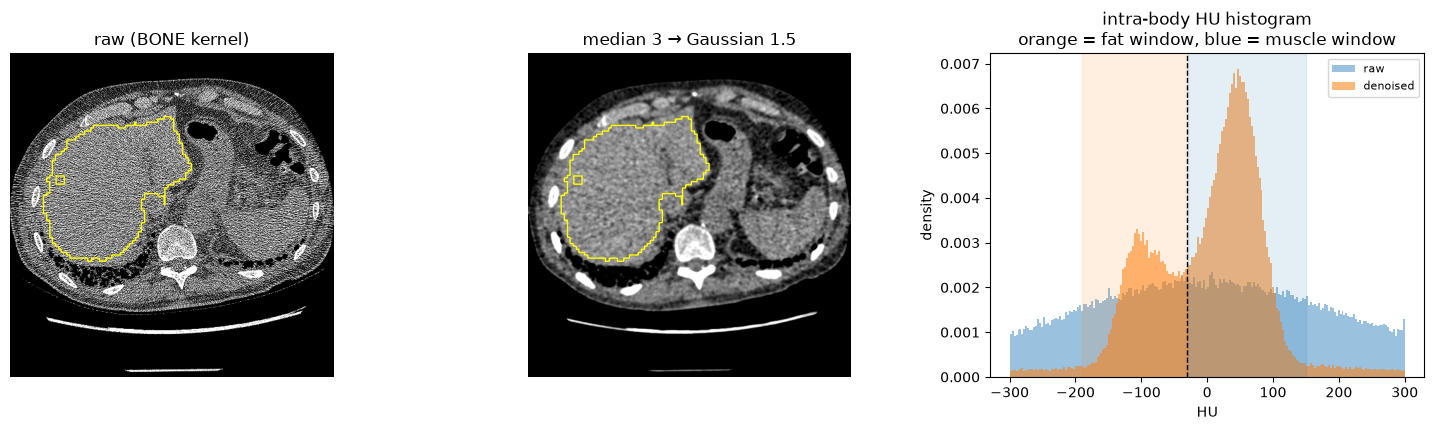

In [6]:
def denoise(slice2d):
    # Median (kills salt-and-pepper / streak speckle), then a mild Gaussian (kills residual grain).
    return ndi.gaussian_filter(ndi.median_filter(slice2d, size=3), sigma=1.5)

liver = load_mask("liver")
k_ref = int(np.argmax(liver.sum(axis=(1, 2))))                        # slice with the most liver
roi   = ndi.binary_erosion(liver[k_ref], structure=np.ones((9, 9)))   # ~3 mm in, away from vessels/capsule

raw_hu, den_hu = vol[k_ref][roi], denoise(vol[k_ref])[roi]
print(f"liver ROI on slice k={k_ref}: {roi.sum()} pixels")
print(f"raw      : mean {raw_hu.mean():7.1f} HU   sd {raw_hu.std():6.1f} HU")
print(f"denoised : mean {den_hu.mean():7.1f} HU   sd {den_hu.std():6.1f} HU")
print(f"-> noise reduced {raw_hu.std()/den_hu.std():.1f}x while the mean HU moved only "
      f"{abs(raw_hu.mean()-den_hu.mean()):.2f} HU")
print(f"-> liver voxels falling inside the FAT window: "
      f"{(raw_hu < -30).mean()*100:.1f}% raw  ->  {(den_hu < -30).mean()*100:.1f}% denoised")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
ax[0].imshow(vol[k_ref], cmap="gray", vmin=-160, vmax=240); ax[0].set_title("raw (BONE kernel)")
ax[1].imshow(denoise(vol[k_ref]), cmap="gray", vmin=-160, vmax=240); ax[1].set_title("median 3 → Gaussian 1.5")
for a in ax[:2]:
    a.contour(roi, levels=[0.5], colors="yellow", linewidths=1.0); a.axis("off")
body_ref = vol[k_ref] > HU_AIR
ax[2].hist(vol[k_ref][body_ref].ravel(), bins=200, range=(-300, 300), alpha=.45, density=True, label="raw")
ax[2].hist(denoise(vol[k_ref])[body_ref].ravel(), bins=200, range=(-300, 300), alpha=.55, density=True, label="denoised")
ax[2].axvspan(*HU_FAT, color="tab:orange", alpha=.12)
ax[2].axvspan(*HU_MUSCLE, color="tab:blue", alpha=.12)
ax[2].axvline(-30, color="k", ls="--", lw=1)
ax[2].set_xlabel("HU"); ax[2].set_ylabel("density"); ax[2].legend(fontsize=8)
ax[2].set_title("intra-body HU histogram\norange = fat window, blue = muscle window")
plt.tight_layout(); plt.show()

**Read the histogram.** After denoising, the two peaks — fat around −100 HU and soft tissue around
+50 HU — separate into a clean bimodal distribution and the −30 HU boundary between the windows falls
into the valley between them. On the raw histogram that valley is filled in by noise, and a large
fraction of *liver* voxels is misclassified as fat. That is the justification for the filter — not
aesthetics.

The price: smoothing blurs thin structures, so the thinnest fat planes are lost and areas shift by a few
percent. Body-composition studies therefore standardise on a **soft (B30f-like) kernel**. If you have a
choice at reconstruction time, take the soft-kernel series.

## 5. Stage `image` (b) — choosing the anatomical level

Body composition is **level dependent**: muscle and fat areas change by tens of cm² over a few
centimetres of table travel. A measurement is therefore meaningless without a stated level, and the
field has standardised on the **third lumbar vertebra (L3)**, because the L3 cross-sectional muscle area
correlates best with whole-body muscle mass (Shen 2004; Mourtzakis 2008).

Historically this slice was picked by hand. TotalSegmentator labels every vertebra separately, so the
level can be selected **automatically and reproducibly**: take the mask of the target vertebra and use
its centroid to index the slice.

In [7]:
levels = []
for n in [n for n in masks_total if n.startswith("vertebrae_")]:
    m = load_mask(n)
    if m is None or m.sum() < MIN_VERTEBRA_VOX:      # skip vertebrae only clipped by the FOV edge
        continue
    kc = float(ndi.center_of_mass(m)[0])                                   # centroid slice index
    z  = ct.TransformContinuousIndexToPhysicalPoint((0.0, 0.0, kc))[2]     # patient coordinate (mm)
    levels.append(dict(vertebra=n, voxels=int(m.sum()), slice=kc, z_mm=z))

levels = pd.DataFrame(levels).sort_values("z_mm").reset_index(drop=True)   # inferior -> superior
display(levels.head(8))

if TARGET_VERTEBRA in set(levels.vertebra):
    row, note = levels[levels.vertebra == TARGET_VERTEBRA].iloc[0], "target level found"
else:
    row  = levels.iloc[0]        # the most inferior labelled vertebra in the FOV
    note = (f"{TARGET_VERTEBRA} is NOT in this field of view — this is a chest CT. "
            f"Falling back to the most inferior vertebra available.")

LEVEL_NAME, LEVEL_K = row.vertebra, int(round(row.slice))
print(f"\n{note}")
print(f"analysis level : {LEVEL_NAME}   slice k={LEVEL_K}   z={row.z_mm:.1f} mm")

,vertebra,voxels,slice,z_mm
0,vertebrae_T12,10806,1.088932,-348.860679
1,vertebrae_T11,11592,4.415200,-315.597999
2,vertebrae_T10,9529,7.311260,-286.637396
3,vertebrae_T9,9424,10.072687,-259.023132
4,vertebrae_T8,8877,12.660358,-233.146418
5,vertebrae_T7,7220,15.199030,-207.759695
6,vertebrae_T6,7426,17.717479,-182.575209
7,vertebrae_T5,6217,20.111951,-158.630489



vertebrae_L3 is NOT in this field of view — this is a chest CT. Falling back to the most inferior vertebra available.
analysis level : vertebrae_T12   slice k=1   z=-348.9 mm


> **Read this before you quote a number.** The series is a *chest* CT, so there is no L3 in the field of
> view and the pipeline falls back to the most inferior labelled vertebra (T12, upper abdomen).
> Everything downstream is anatomically correct **at that level**, but the numbers are *not* comparable
> to published L3 cut-points. Run this identical notebook on an abdominal or whole-body CT and
> `TARGET_VERTEBRA = "vertebrae_L3"` resolves by itself — that is the entire point of selecting the level
> from a label rather than from a hard-coded slice index.

## 6. Stage `image` (c) — compartment segmentation

Now the anatomy-guided recipe. For each slice:

| Step | Operation | Chapter |
|---|---|---|
| 1 | **Body** = TotalSegmentator `body_trunc`, holes filled → table and arms are gone | 2 |
| 2 | **Denoise** median 3 → Gaussian 1.5 | 2 |
| 3 | **Visceral cavity** = union of all TS organ masks, dilated 10 mm, closed and hole-filled | 2 |
| 4 | **Fat** / **muscle** = HU windows inside the body mask | 2 |
| 5 | **SAT** = fat connected to the outer 20 mm rim **and** outside the cavity (connected components!) | 3 |
| 6 | **VAT** = fat inside the cavity, minus the organs themselves | 3 |
| 7 | **SM** = muscle outside the cavity, minus bone, organs and the 2 mm skin rim, **plus** the TS paraspinal muscle masks | 2, 3 |
| 8 | **IMAT** = fat-density voxels inside the closed muscle envelope | 2 |
| 9 | **Clean-up** = morphological opening + removal of components < 50 px | 2 |

Step 5 is the interesting one. Subcutaneous and visceral fat are indistinguishable by HU, but they are
*topologically* different: subcutaneous fat is a ring that touches the outer body surface, visceral fat
is not. A connected-component labelling followed by "does this component touch the outer rim?" separates
them — a Chapter-3 measurement idea used as a Chapter-2 segmentation rule.

In [8]:
# --- structure groups -------------------------------------------------------------
ORGANS = ["liver", "spleen", "stomach", "pancreas", "kidney_left", "kidney_right",
          "colon", "small_bowel", "duodenum", "adrenal_gland_left", "adrenal_gland_right",
          "aorta", "inferior_vena_cava", "portal_vein_and_splenic_vein", "gallbladder",
          "esophagus", "urinary_bladder", "heart", "spinal_cord", "trachea",
          "lung_upper_lobe_left", "lung_lower_lobe_left",
          "lung_upper_lobe_right", "lung_middle_lobe_right", "lung_lower_lobe_right"]
BONES  = (["vertebrae_" + v for v in "L5 L4 L3 L2 L1 T12 T11 T10 T9 T8".split()]
          + [f"rib_{s}_{i}" for s in ("left", "right") for i in range(1, 13)]
          + ["sternum", "costal_cartilages", "scapula_left", "scapula_right",
             "humerus_left", "humerus_right", "clavicula_left", "clavicula_right",
             "hip_left", "hip_right", "sacrum"])
TS_MUSCLES = ["autochthon_left", "autochthon_right", "iliopsoas_left", "iliopsoas_right",
              "gluteus_maximus_left", "gluteus_maximus_right"]

ORGAN_VOL = union_masks(ORGANS)
BONE_VOL  = union_masks(BONES)
MUSC_VOL  = union_masks(TS_MUSCLES)
BODY_VOL  = load_mask("body_trunc", BODY_DIR)
if BODY_VOL is None:                                   # fallback if the 'body' task is unavailable
    BODY_VOL = np.stack([ndi.binary_fill_holes(v > HU_AIR) for v in vol])

# --- morphology helpers -----------------------------------------------------------
def disk(radius_mm):
    r = max(1, int(round(radius_mm / sx)))
    yy, xx = np.ogrid[-r:r + 1, -r:r + 1]
    return xx ** 2 + yy ** 2 <= r ** 2

def clean(mask, open_mm=1.5, min_px=50):
    # Morphological opening + removal of specks — Chapter 2/3 mask hygiene.
    mask = ndi.binary_opening(mask, structure=disk(open_mm))
    lab, n = ndi.label(mask)
    if n == 0:
        return mask
    sizes = ndi.sum(mask, lab, range(1, n + 1))
    return np.isin(lab, [i + 1 for i, s in enumerate(sizes) if s >= min_px])

# --- the segmentation itself ------------------------------------------------------
def segment_slice(k):
    raw  = vol[k]
    hu   = denoise(raw)
    body = ndi.binary_fill_holes(BODY_VOL[k])
    org  = ORGAN_VOL[k]

    # 3. visceral cavity: grow the organ union until it closes into one cavity, then fill it
    cavity = ndi.binary_dilation(org, structure=disk(10))
    cavity = ndi.binary_fill_holes(ndi.binary_closing(cavity, structure=disk(10))) & body

    # 4. HU windows
    fat    = body & (hu >= HU_FAT[0])    & (hu <= HU_FAT[1])
    muscle = body & (hu >= HU_MUSCLE[0]) & (hu <= HU_MUSCLE[1])

    # 5. SAT: fat components that touch the outer 20 mm rim and lie outside the cavity
    rim    = body & ~ndi.binary_erosion(body, structure=disk(20))
    lab, n = ndi.label(fat)
    sat    = np.zeros_like(fat)
    if n:
        touching = set(np.unique(lab[rim & fat])) - {0}
        sat = np.isin(lab, list(touching)) & fat & ~cavity

    # 6. VAT: fat inside the cavity that is not an organ
    vat = fat & cavity & ~org & ~sat

    # 7. SM: muscle-density tissue in the wall + the paraspinal masks from TotalSegmentator
    skin = body & ~ndi.binary_erosion(body, structure=disk(2))
    sm   = ((muscle & ~cavity) | MUSC_VOL[k]) & body & ~BONE_VOL[k] & ~org & ~skin & ~sat

    sat, vat, sm = clean(sat), clean(vat), clean(sm)

    # 8. IMAT: fat-density voxels enclosed by the muscle envelope (inter/intra-muscular fat)
    envelope = ndi.binary_fill_holes(ndi.binary_closing(sm, structure=disk(8)))
    imat = envelope & (hu >= HU_IMAT[0]) & (hu <= HU_IMAT[1]) & ~sat & ~vat
    imat = clean(imat, open_mm=1.0, min_px=10)

    return dict(raw=raw, hu=hu, body=body, cavity=cavity, organs=org,
                sat=sat, vat=vat, sm=sm, imat=imat)

seg = segment_slice(LEVEL_K)
print(f"segmented slice k={LEVEL_K} ({LEVEL_NAME})")

segmented slice k=1 (vertebrae_T12)


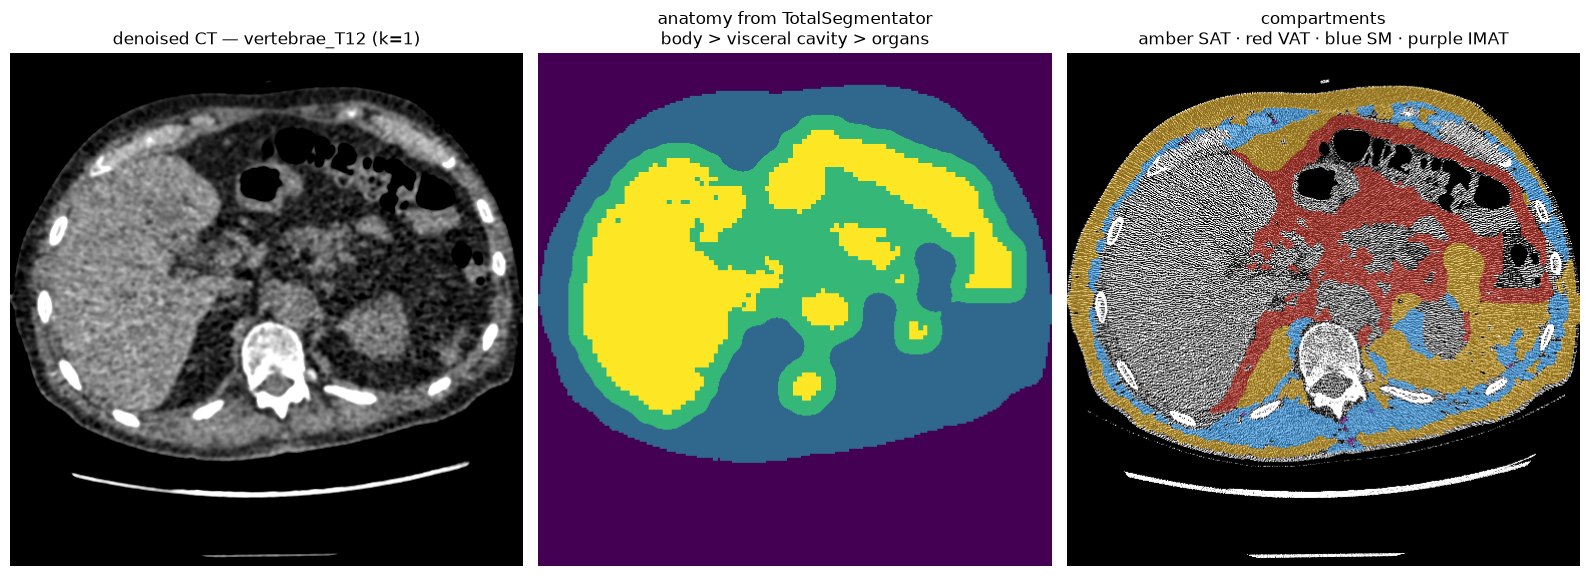

In [9]:
def overlay(seg, alpha=0.55):
    g   = np.clip((seg["raw"] + 160) / 400.0, 0, 1)          # soft-tissue window as greyscale
    rgb = np.dstack([g, g, g])
    for mask, color in [(seg["sat"],  (1.00, 0.78, 0.20)),   # amber  — subcutaneous fat
                        (seg["vat"],  (0.90, 0.25, 0.20)),   # red    — visceral fat
                        (seg["sm"],   (0.20, 0.65, 1.00)),   # blue   — skeletal muscle
                        (seg["imat"], (0.55, 0.20, 0.75))]:  # purple — intermuscular fat
        rgb[mask] = (1 - alpha) * rgb[mask] + alpha * np.array(color)
    return rgb

fig, ax = plt.subplots(1, 3, figsize=(16, 5.6))
ax[0].imshow(seg["hu"], cmap="gray", vmin=-160, vmax=240)
ax[0].set_title(f"denoised CT — {LEVEL_NAME} (k={LEVEL_K})")
ax[1].imshow(seg["body"].astype(int) + seg["cavity"].astype(int) + seg["organs"].astype(int), cmap="viridis")
ax[1].set_title("anatomy from TotalSegmentator\nbody > visceral cavity > organs")
ax[2].imshow(overlay(seg))
ax[2].set_title("compartments\namber SAT · red VAT · blue SM · purple IMAT")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

Look at the middle panel: the cavity boundary follows the *inner* surface of the abdominal wall, which is
exactly the line no threshold can find. In the right panel the liver stays unlabelled — it is
soft-tissue density like muscle, and only the anatomical prior keeps it out of the muscle mask.

## 7. Stage `features` (a) — the classical body composition metrics

Now the Chapter-3 part: turn masks into numbers. Every area is *pixel count × pixel area*; every density
is the mean HU of the **raw** (un-smoothed) image inside the mask — smoothing is for finding the mask,
never for measuring intensity.

The normalised indices are what actually get compared across patients:

$$\text{SMI}\;[\mathrm{cm^2/m^2}] = \frac{\text{SMA}}{\text{height}^2}
\qquad
\text{VAT/SAT ratio} = \frac{\text{VAT area}}{\text{SAT area}}$$

In [10]:
def compartment_metrics(seg, level_name, k):
    raw = seg["raw"]
    out = {"level": level_name, "slice": k}
    for key, label in [("sm", "SM"), ("sat", "SAT"), ("vat", "VAT"), ("imat", "IMAT")]:
        m = seg[key]
        out[f"{label}_area_cm2"] = m.sum() * PIXEL_AREA_CM2
        out[f"{label}_mean_HU"]  = float(raw[m].mean()) if m.any() else np.nan
    out["TAT_area_cm2"]  = out["SAT_area_cm2"] + out["VAT_area_cm2"]
    out["VAT_SAT_ratio"] = out["VAT_area_cm2"] / out["SAT_area_cm2"] if out["SAT_area_cm2"] else np.nan
    out["body_area_cm2"] = seg["body"].sum() * PIXEL_AREA_CM2
    out["SMI_cm2_m2"]    = out["SM_area_cm2"] / PATIENT_HEIGHT_M ** 2
    out["FMI_cm2_m2"]    = out["TAT_area_cm2"] / PATIENT_HEIGHT_M ** 2
    out["muscle_attenuation_HU"] = out["SM_mean_HU"]          # a.k.a. SMD
    return out

metrics = compartment_metrics(seg, LEVEL_NAME, LEVEL_K)
display(pd.DataFrame({"value": pd.Series(metrics)}))

print(f"Interpretation for this slice ({LEVEL_NAME}):")
print(f"  skeletal muscle area  SMA = {metrics['SM_area_cm2']:7.1f} cm^2"
      f"   -> SMI {metrics['SMI_cm2_m2']:.1f} cm^2/m^2 (at h = {PATIENT_HEIGHT_M} m)")
print(f"  muscle radiodensity   SMD = {metrics['muscle_attenuation_HU']:7.1f} HU")
print(f"  subcutaneous fat      SAT = {metrics['SAT_area_cm2']:7.1f} cm^2")
print(f"  visceral fat          VAT = {metrics['VAT_area_cm2']:7.1f} cm^2"
      f"   -> VAT/SAT = {metrics['VAT_SAT_ratio']:.2f}")
print(f"  intermuscular fat    IMAT = {metrics['IMAT_area_cm2']:7.1f} cm^2")

,value
level,vertebrae_T12
slice,1
SM_area_cm2,81.476319
SM_mean_HU,26.918312
SAT_area_cm2,149.300907
SAT_mean_HU,-99.593491
VAT_area_cm2,99.375065
VAT_mean_HU,-103.327507
IMAT_area_cm2,0.663862
IMAT_mean_HU,-85.871796


Interpretation for this slice (vertebrae_T12):
  skeletal muscle area  SMA =    81.5 cm^2   -> SMI 28.2 cm^2/m^2 (at h = 1.7 m)
  muscle radiodensity   SMD =    26.9 HU
  subcutaneous fat      SAT =   149.3 cm^2
  visceral fat          VAT =    99.4 cm^2   -> VAT/SAT = 0.67
  intermuscular fat    IMAT =     0.7 cm^2


### Published cut-points (defined at L3, on abdominal CT)

| Marker | Threshold | Population / reference |
|---|---|---|
| **SMI** (sarcopenia) | < 52.4 cm²/m² (men), < 38.5 cm²/m² (women) | Prado *et al.*, Lancet Oncol 2008 |
| **SMI** (sarcopenia) | < 43 (men, BMI < 25), < 53 (men, BMI ≥ 25), < 41 (women) | Martin *et al.*, JCO 2013 |
| **SMD** (myosteatosis) | < 41 HU (BMI < 25), < 33 HU (BMI ≥ 25) | Martin *et al.*, JCO 2013 |
| **VAT** (visceral obesity) | > 100–130 cm² | Doyle *et al.*, 2013; Kaess *et al.*, 2012 |
| **VAT/SAT ratio** | > 0.4 associated with cardiometabolic risk | Kaess *et al.*, Diabetologia 2012 |

**Do not apply these to the table above.** They are defined at L3, on soft-kernel portal-venous-phase
abdominal CT, stratified by sex and BMI. Our measurement sits at a different level on a sharp-kernel
non-contrast chest CT, and the SMI additionally depends on a height we had to assume. The table is here
so you know what the numbers are *for* — and so the gap between a demo pipeline and a validated one is
explicit rather than implied.

Note also how small **IMAT** comes out. Part of that is real (little fat infiltration at this level in
this patient) and part is method: the Gaussian smoothing that made thresholding possible also erases the
thinnest intramuscular fat streaks. A measurement that depends this strongly on a preprocessing choice
should be reported together with that preprocessing, or not reported at all.

## 8. Level dependence — why the vertebra matters

Repeat the segmentation on every slice of the stack and plot area versus table position. This single
figure is the strongest argument for automatic level selection.

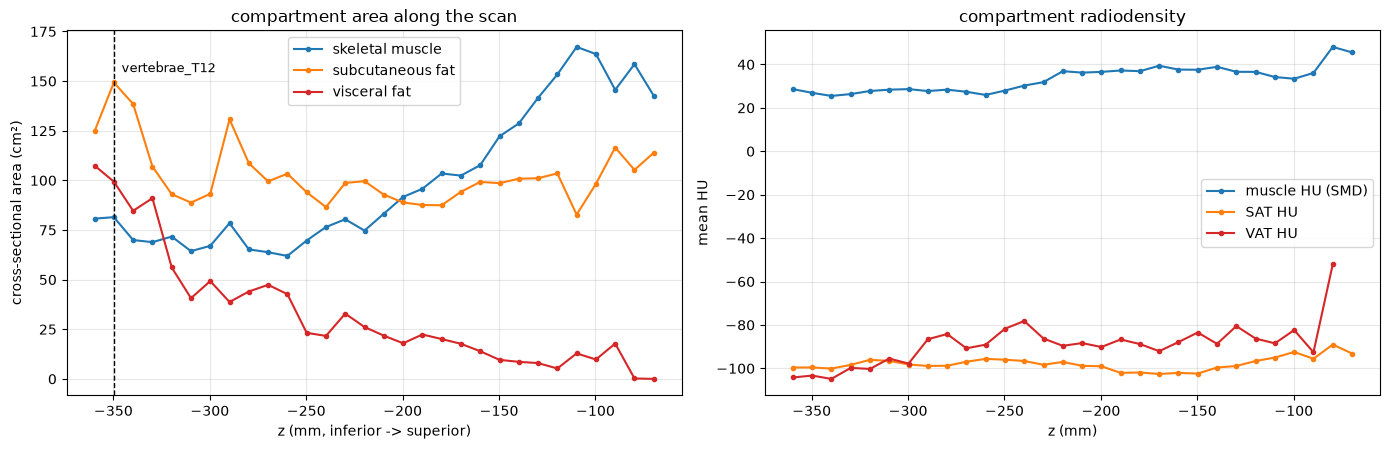

muscle area within +/-1 slice (+/-10 mm) of vertebrae_T12: 69.9 .. 81.5 cm^2 (15% spread)
A one-slice error in level selection is a real measurement error — automate the level.


In [11]:
rows = []
for k in range(vol.shape[0]):
    s = segment_slice(k)
    m = compartment_metrics(s, "", k)
    m["z_mm"] = ct.TransformIndexToPhysicalPoint((0, 0, k))[2]
    rows.append(m)
profile = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
for col, lbl, c in [("SM_area_cm2",  "skeletal muscle",  "tab:blue"),
                    ("SAT_area_cm2", "subcutaneous fat", "tab:orange"),
                    ("VAT_area_cm2", "visceral fat",     "tab:red")]:
    ax[0].plot(profile.z_mm, profile[col], "o-", ms=3, label=lbl, color=c)
ax[0].axvline(profile.z_mm[LEVEL_K], color="k", ls="--", lw=1)
ax[0].annotate(LEVEL_NAME, (profile.z_mm[LEVEL_K] + 4, ax[0].get_ylim()[1] * 0.88), fontsize=9)
ax[0].set_xlabel("z (mm, inferior -> superior)"); ax[0].set_ylabel("cross-sectional area (cm²)")
ax[0].set_title("compartment area along the scan"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(profile.z_mm, profile.SM_mean_HU,  "o-", ms=3, color="tab:blue",   label="muscle HU (SMD)")
ax[1].plot(profile.z_mm, profile.SAT_mean_HU, "o-", ms=3, color="tab:orange", label="SAT HU")
ax[1].plot(profile.z_mm, profile.VAT_mean_HU, "o-", ms=3, color="tab:red",    label="VAT HU")
ax[1].set_xlabel("z (mm)"); ax[1].set_ylabel("mean HU"); ax[1].set_title("compartment radiodensity")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

near = profile.iloc[max(0, LEVEL_K - 1): LEVEL_K + 2]
print(f"muscle area within +/-1 slice (+/-{sz:.0f} mm) of {LEVEL_NAME}: "
      f"{near.SM_area_cm2.min():.1f} .. {near.SM_area_cm2.max():.1f} cm^2 "
      f"({(near.SM_area_cm2.max()-near.SM_area_cm2.min())/near.SM_area_cm2.mean()*100:.0f}% spread)")
print("A one-slice error in level selection is a real measurement error — automate the level.")

Above the diaphragm the "visceral" compartment stops being abdominal at all (it becomes mediastinal fat)
and the "wall" muscle becomes intercostal and pectoral muscle. The pipeline still produces numbers up
there; they are simply no longer *body composition* numbers. Producing a plausible number outside its
domain of validity is the most common failure mode of an automated imaging pipeline — which is why the
level is tied to a labelled vertebra rather than to a slice index.

## 9. Stage `features` (b) — from areas to radiomics with `qradiomics`

Area and mean HU are two numbers per compartment. **Radiomics** asks what else is in there: is the muscle
uniformly dense, or a patchwork of fat-infiltrated fascicles? Two patients can share an SMD of 30 HU
while one has homogeneous, mildly fatty muscle and the other a bimodal mix of normal and severely
infiltrated tissue — a difference that texture features (GLCM, GLRLM, GLSZM, NGTDM) capture and the mean
does not.

`qradiomics` drives PyRadiomics through a **manifest**: one row per (image, mask) pair with canonical
column names, so the same command scales from one patient to a thousand.

In [12]:
from qradiomics.manifest import MANIFEST_COLUMNS, write_manifest

# analysis slab: the target slice +/- SLAB_HALF_SLICES (a single-slice ROI has no 3D texture)
k0, k1 = max(0, LEVEL_K - SLAB_HALF_SLICES), min(vol.shape[0], LEVEL_K + SLAB_HALF_SLICES + 1)
slab = {key: np.zeros(vol.shape, np.uint8) for key in ("SM", "SAT", "VAT")}
for k in range(k0, k1):
    s = segment_slice(k)
    for key in slab:
        slab[key][k] = s[key.lower()]
print(f"radiomics slab: slices {k0}..{k1-1}  ({(k1-k0)*sz:.0f} mm centred on {LEVEL_NAME})")

# write image + masks as NRRD on the identical grid (PyRadiomics checks geometry strictly)
sitk.WriteImage(sitk.Cast(ct, sitk.sitkInt16), str(CT_NRRD), True)
mask_paths = {}
for key, arr in slab.items():
    m = sitk.GetImageFromArray(arr); m.CopyInformation(ct)
    p = WORK / f"{PATIENT}_{key}-label.nrrd"
    sitk.WriteImage(m, str(p), True)
    mask_paths[key] = p
    print(f"  {key:4s} {arr.sum():7d} voxels  ->  {p}")

rows = []
for key, p in mask_paths.items():
    row = {c: "" for c in MANIFEST_COLUMNS}
    row.update(patient_id=PATIENT, modality="CT", image_path=str(CT_NRRD), image_tag="CT",
               study_id=LEVEL_NAME, mask_path=str(p), mask_tag=key, mask_label="1")
    rows.append(row)
MANIFEST = WORK / "bodycomp_manifest.csv"
write_manifest(rows, MANIFEST)
display(pd.read_csv(MANIFEST)[["patient_id", "modality", "image_path", "mask_path", "mask_tag"]])

radiomics slab: slices 0..2  (30 mm centred on vertebrae_T12)


  SM     54548 voxels  ->  work/ID00007637202177411956430_SM-label.nrrd
  SAT    96936 voxels  ->  work/ID00007637202177411956430_SAT-label.nrrd
  VAT    68499 voxels  ->  work/ID00007637202177411956430_VAT-label.nrrd


,patient_id,modality,image_path,mask_path,mask_tag
0,ID00007637202177411956430,CT,work/ID00007637202177411956430_CT.nrrd,work/ID00007637202177411956430_SM-label.nrrd,SM
1,ID00007637202177411956430,CT,work/ID00007637202177411956430_CT.nrrd,work/ID00007637202177411956430_SAT-label.nrrd,SAT
2,ID00007637202177411956430,CT,work/ID00007637202177411956430_CT.nrrd,work/ID00007637202177411956430_VAT-label.nrrd,VAT


In [13]:
FEATURES = WORK / "bodycomp_features.csv"
r = subprocess.run(["qr", "extract", "-m", str(MANIFEST), "-p", "ct-default",
                    "-o", str(FEATURES), "-j", "3"], capture_output=True, text=True)
r.check_returncode()
print("\n".join(r.stdout.strip().splitlines()[-2:]))

feat = pd.read_csv(FEATURES)
feat.insert(1, "compartment", list(mask_paths))        # rows follow the manifest order
print(f"\nfeature table: {feat.shape[0]} ROIs x {feat.shape[1]-2} features")
print("feature families:", sorted({c.split('_')[1] for c in feat.columns if c.startswith('original_')}))

Extraction extracted: 3 processed, 0 failed, 0 skipped
Features (1409 per patient) -> /home/wxc151/projects/Biomedical-Image-Analysis-in-Python/work/bodycomp_features.csv

feature table: 3 ROIs x 1409 features
feature families: ['firstorder', 'glcm', 'gldm', 'glrlm', 'glszm', 'ngtdm', 'shape']


`ct-default` is one of the pattern templates shipped with `qradiomics` (`qr pattern list`). A pattern is
the *versioned record of an extraction*: image types, feature classes and PyRadiomics settings in one
YAML file. `ct-default` asks for the full feature set on the original image plus exponential, gradient,
LBP, logarithm, square, square-root and wavelet transforms — which is why the table is ~1,400 columns
wide — and it **resamples to 1 × 1 × 1 mm with a B-spline interpolator** before extracting.

That resampling matters, and the next cell makes it visible.

### Sanity check before interpretation

A feature table is only trustworthy if a feature you can compute by hand matches. `firstorder_Mean` on
the muscle ROI must reproduce the mean HU we measured with NumPy — *exactly* on the native grid, and to
within a fraction of an HU through the CLI, where the pattern's isotropic resampling has slightly
redistributed the voxels.

In [14]:
from qradiomics.atomic import extract_features

sm_row  = feat[feat.compartment == "SM"].iloc[0]
sm_slab = slab["SM"].astype(bool)

native = extract_features(sitk.ReadImage(str(CT_NRRD)),          # native 0.65 x 0.65 x 10 mm, no resampling
                          sitk.ReadImage(str(mask_paths["SM"])))

print(f"NumPy   vol[mask].mean()                     : {vol[sm_slab].mean():9.4f} HU")
print(f"qradiomics.atomic (native grid)              : {native['original_firstorder_Mean']:9.4f} HU")
print(f"qr extract -p ct-default (resampled to 1 mm) : {float(sm_row['original_firstorder_Mean']):9.4f} HU")
print(f"\nnative vs NumPy    : {abs(native['original_firstorder_Mean']-vol[sm_slab].mean()):.2e} HU (identical)")
print(f"resampled vs NumPy : {abs(float(sm_row['original_firstorder_Mean'])-vol[sm_slab].mean()):.3f} HU "
      f"(B-spline interpolation across a 10 mm slice gap)")

NumPy   vol[mask].mean()                     :   27.0899 HU
qradiomics.atomic (native grid)              :   27.0899 HU
qr extract -p ct-default (resampled to 1 mm) :   27.2451 HU

native vs NumPy    : 0.00e+00 HU (identical)
resampled vs NumPy : 0.155 HU (B-spline interpolation across a 10 mm slice gap)


The 0.1–0.2 HU offset is not a bug — it is the pattern doing what it promised. But it is a warning:
interpolating a **10 mm** slice spacing up to 1 mm invents nine slices out of every ten, and 3D texture
features computed on that grid describe the interpolator as much as the patient. On anisotropic data,
either extract in 2D (`force2D`) or use a pattern without aggressive z-resampling — and always report
which one you used.

In [15]:
# a compact, interpretable subset, one column per compartment
KEEP = {
    "original_firstorder_Mean":              "mean HU (SMD for muscle)",
    "original_firstorder_Median":            "median HU",
    "original_firstorder_10Percentile":      "10th percentile HU (fatty tail)",
    "original_firstorder_StandardDeviation": "HU spread",
    "original_firstorder_Skewness":          "HU skewness",
    "original_firstorder_Entropy":           "intensity entropy (heterogeneity)",
    "original_glcm_Contrast":                "GLCM contrast (local HU variation)",
    "original_glcm_JointEntropy":            "GLCM joint entropy (texture disorder)",
    "original_glrlm_GrayLevelNonUniformity": "GLRLM grey-level non-uniformity",
    "original_glszm_ZoneEntropy":            "GLSZM zone entropy (zone-size disorder)",
    "original_ngtdm_Busyness":               "NGTDM busyness (rapid HU change)",
    "original_shape_SurfaceVolumeRatio":     "surface-to-volume ratio",
}
sel = (feat.set_index("compartment")[[c for c in KEEP if c in feat.columns]]
           .rename(columns=KEEP).T)
display(sel.round(3))

compartment,SM,SAT,VAT
mean HU (SMD for muscle),27.245,-99.882,-96.253
median HU,27.000,-100.000,-97.000
10th percentile HU (fatty tail),-162.000,-321.000,-293.000
HU skewness,0.024,-0.005,0.047
intensity entropy (heterogeneity),4.672,4.881,4.738
GLCM contrast (local HU variation),75.235,102.467,86.787
GLCM joint entropy (texture disorder),9.089,9.512,9.217
GLRLM grey-level non-uniformity,10189.678,11072.854,17505.834
GLSZM zone entropy (zone-size disorder),7.090,7.126,7.181
NGTDM busyness (rapid HU change),9.978,8.977,12.572


**How to read this.** `mean HU` in the SM column is the classical SMD — everything else is new
information. `10th percentile HU` and `skewness` respond to a fatty tail in the muscle histogram before
the mean moves at all. `GLCM contrast` and `NGTDM busyness` are high when dense and fatty voxels
alternate over short distances — the imaging signature of myosteatosis. In published work these texture
descriptors of the L3 muscle compartment have added prognostic information on top of SMA and SMD alone.

Extracting the same features from **SAT** and **VAT** is not a formality either: adipose texture reflects
fibrous septa and inflammatory infiltration, and VAT texture has been associated with metabolic risk
independently of VAT area. Note in the table how the two fat compartments differ in
`GLRLM grey-level non-uniformity` and `busyness` despite nearly identical mean HU — that difference is
exactly the information an area-only analysis throws away.

## 10. Stage `modeling` — scaling from one patient to a cohort

Nothing above is patient-specific except the paths, so the same steps run over a cohort with the
`qradiomics` cohort commands. For a directory of already-converted patients:

```bash
# 1. build a manifest by globbing image/mask pairs
qr convert manifest-from-dir -d work/ \
     --image-glob '*_CT.nrrd' --mask-glob '*_SM-label.nrrd' -o cohort_manifest.csv

# 2. extract features for the whole cohort in parallel
qr extract -m cohort_manifest.csv -p ct-default -o cohort_features.csv -j 16

# 3. join the imaging features with the clinical table
qr results merge -f cohort_features.csv -c clinical.csv \
     --clinical-id-col PatientID --time-col OS_months --event-col OS_event \
     -o analysis_ready.csv

# 4a. is muscle mass associated with survival?  (univariate Cox proportional hazards)
qr analyze survival -i analysis_ready.csv --outcome OS_months --event OS_event -o cox.csv

# 4b. or a multivariable, cross-validated, leakage-safe model
qr ml train    -i analysis_ready.csv --task survival --cv 5 -o model/
qr ml evaluate -i heldout.csv -m model/ -o evaluation.json
```

And the whole chain can be emitted as a per-patient-parallel Nextflow pipeline instead of a shell loop:

```bash
qr workflow plan     -t dicom_to_ml -d /data/cohort -c clinical.csv --roi GTV -o plan.json
qr workflow scaffold -p plan.json -e nextflow -o pipeline.nf
qr workflow run       plan.json --executor nextflow
```

The manifest is the contract between the stages. Once the compartment masks are on disk under a
consistent naming convention, the analysis is a four-command pipeline no matter how many patients there
are.

In [16]:
# The same extraction through the Python API — this is what you call from your own code
# (e.g. a longitudinal body-composition study) instead of shelling out to the CLI.
from qradiomics.atomic import load_image_and_mask, preprocess_pair

image, mask        = load_image_and_mask(CT_NRRD, mask_paths["SM"])
crop_img, crop_msk = preprocess_pair(image, mask, pad_mm=10.0)     # bounding-box crop around the ROI
fx = extract_features(crop_img, crop_msk)

print(f"{len(fx)} features from qradiomics.atomic.extract_features")
print(f"mean HU  : {fx['original_firstorder_Mean']:.2f}")
print(f"crop     : {image.GetSize()} -> {crop_img.GetSize()} voxels "
      f"({np.prod(crop_img.GetSize())/np.prod(image.GetSize())*100:.0f}% of the volume)")

1409 features from qradiomics.atomic.extract_features
mean HU  : 27.09
crop     : (512, 512, 30) -> (511, 383, 4) voxels (10% of the volume)


## 11. Limitations — read this before reusing any of it

| # | Limitation | Consequence | Mitigation |
|---|---|---|---|
| 1 | **No L3 in the field of view** (chest CT) | numbers not comparable to published cut-points | run on abdominal / whole-body CT; `TARGET_VERTEBRA` then resolves automatically |
| 2 | **10 mm slice spacing** | level accurate only to ±5 mm; 3D texture partly describes the interpolator | use ≤ 5 mm reconstructions, or extract in 2D |
| 3 | **Sharp (BONE) kernel, no contrast** | heavy noise forced aggressive smoothing; thin fat planes and IMAT are underestimated | standardise on a soft kernel and a fixed contrast phase |
| 4 | **Compartments derived by rule, not learned** | wall muscle can leak into an organ edge and vice versa; bowel contents in the fat window inflate VAT | TotalSegmentator's licensed `tissue_types` task, or a dedicated BCA model |
| 5 | **Dilated organ union as the cavity** | retroperitoneal fat can land on the wrong side of the boundary | full-resolution TS (drop `--fast`) tightens organ borders substantially |
| 6 | **Height unknown** (not in the public header) | SMI is only as good as the height you supply | take height from the clinical table, never from the image |
| 7 | **Single-slice measurement** | represents whole-body composition only by correlation | report the level with every number; use a fixed slab for longitudinal work |
| 8 | **Vendor / kernel / phase effects** | features drift between scanners | harmonise (e.g. ComBat) before pooling cohorts; test–retest your feature set |

Points 3, 4 and 8 are not exotic caveats — they are the reasons a body-composition pipeline that works
beautifully in one hospital produces different numbers in the next one.

## 12. Exercises

1. **Threshold sensitivity.** Re-run `segment_slice` with the muscle window set to (−29, 120) and then
   (0, 150). How many cm² does SMA move? Is SMD more or less stable than the area?
2. **The value of the anatomical prior.** Replace `BODY_VOL` with a plain `hu > -500` threshold and
   re-plot the overlay. Where does the scanner table end up, and what does it do to SAT?
3. **Resolution.** Re-run TotalSegmentator without `--fast` (1.5 mm model) and compare the visceral
   cavity boundary and the resulting VAT area. Is the extra runtime worth it here?
4. **Chapter 4 link — longitudinal change.** Given two scans of the same patient, register them
   (`qr register`) and compute ΔSMA, ΔSMD and ΔVAT. Which compartment changes fastest during treatment?
   `qr delta` computes exactly these per-patient differences and trend slopes.
5. **Radiomics vs. the mean.** Which texture features separate SM, SAT and VAT best? Would any of them
   survive a multiple-testing correction in a real cohort?
6. **Reproducibility.** Segment the slice one above and one below the target level and re-extract. How
   much of the feature table changes? That spread is the noise floor against which any biological effect
   must compete.

## 13. References

**Method and clinical validation**

* Shen W, *et al.* Total body skeletal muscle and adipose tissue volumes: estimation from a single
  abdominal cross-sectional image. *J Appl Physiol* 2004;97:2333–2338.
* Mourtzakis M, *et al.* A practical and precise approach to quantification of body composition in
  cancer patients using computed tomography images. *Appl Physiol Nutr Metab* 2008;33:997–1006.
* Prado CMM, *et al.* Prevalence and clinical implications of sarcopenic obesity in patients with solid
  tumours of the respiratory and gastrointestinal tracts. *Lancet Oncol* 2008;9:629–635.
* Martin L, *et al.* Cancer cachexia in the age of obesity: skeletal muscle depletion is a powerful
  prognostic factor, independent of body mass index. *J Clin Oncol* 2013;31:1539–1547.
* Mitsiopoulos N, *et al.* Cadaver validation of skeletal muscle measurement by MRI and computerized
  tomography. *J Appl Physiol* 1998;85:115–122.
* Kaess BM, *et al.* The ratio of visceral to subcutaneous fat, a metric of body fat distribution, is a
  unique correlate of cardiometabolic risk. *Diabetologia* 2012;55:2622–2630.

**Software**

* Wasserthal J, *et al.* TotalSegmentator: robust segmentation of 104 anatomic structures in CT images.
  *Radiology: Artificial Intelligence* 2023;5:e230024. — <https://github.com/wasserth/TotalSegmentator>
* van Griethuysen JJM, *et al.* Computational radiomics system to decode the radiographic phenotype.
  *Cancer Research* 2017;77:e104–e107. (PyRadiomics)
* Choi W. **qradiomics** — radiomics research CLI. <https://github.com/choilab-jefferson/qradiomics>
* Yaniv Z, *et al.* SimpleITK image-analysis notebooks: a collaborative environment for education and
  reproducible research. *J Digit Imaging* 2018;31:290–303.

**Data**

* OSIC Pulmonary Fibrosis Progression (Open Source Imaging Consortium / Kaggle) — the CT series used here.
